<a href="https://colab.research.google.com/github/freditasariph/Praktikum-ADW/blob/main/Tugas_Kelompok_Minggu_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS KELOMPOK — Simulasi dan Pemodelan Deret Waktu Stasioner
### Praktikum Analisis Deret Waktu — Minggu 5

**Kelompok 3**
1. Muhammad Fadel Handiyono — M0501251056
2. Freditasari Purwa Hidayat — M0501251052
3. Putri Aqila — M0501251029

**Seed simulasi = 137** (jumlah dua digit terakhir NIM seluruh anggota: 56 + 52 + 29 = 137)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import shapiro, jarque_bera
from scipy import stats
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

SEED = 137

## Fungsi EACF (Extended Autocorrelation Function)



In [ ]:
def eacf(x, ar_max=5, ma_max=6):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    val = np.full((ar_max + 1, ma_max + 1), np.nan)
    sym = np.empty((ar_max + 1, ma_max + 1), dtype=object)

    for p in range(ar_max + 1):
        for q in range(ma_max + 1):
            k = p + q
            if k == 0:
                w = x.copy()
            else:
                Y = x[k:]
                X = np.column_stack([x[k - i - 1: n - i - 1] for i in range(k)])
                Xd = np.column_stack([np.ones(len(Y)), X])
                coef, *_ = np.linalg.lstsq(Xd, Y, rcond=None)
                if p > 0:
                    phi = coef[1:1 + p]
                    w = x[p:].copy()
                    for i in range(p):
                        w = w - phi[i] * x[p - i - 1: n - i - 1]
                else:
                    w = x.copy()

            lag = q + 1
            if len(w) <= lag + 5:
                sym[p, q] = "."
                continue
            wc = w - w.mean()
            num = np.sum(wc[:-lag] * wc[lag:])
            den = np.sum(wc ** 2)
            rho = num / den if den != 0 else np.nan
            val[p, q] = rho
            thresh = 1.96 / np.sqrt(len(w))
            sym[p, q] = "o" if abs(rho) <= thresh else "x"
    return val, sym


def print_eacf(sym):
    ar_max, ma_max = sym.shape[0] - 1, sym.shape[1] - 1
    print("AR/MA " + " ".join(f"{q:2d}" for q in range(ma_max + 1)))
    for p in range(ar_max + 1):
        print(f"{p:5d} " + "  ".join(sym[p, :]))


def diagnose_residual(resid):
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    arch_p = het_arch(resid, nlags=10)[1]
    runs_stat, runs_p = runstest_1samp(resid, correction=False)
    sh_stat, sh_p = shapiro(resid)
    jb_stat, jb_p = jarque_bera(resid)
    print(f"Ljung-Box (lag 10) : stat={lb['lb_stat'].iloc[0]:.3f}  p-value={lb['lb_pvalue'].iloc[0]:.4f}")
    print(f"ARCH (nlags=10)    : p-value={arch_p:.4f}")
    print(f"Runs test          : stat={runs_stat:.3f}  p-value={runs_p:.4f}")
    print(f"Shapiro-Wilk       : stat={sh_stat:.3f}  p-value={sh_p:.4f}")
    print(f"Jarque-Bera        : stat={jb_stat:.3f}  p-value={jb_p:.4f}")


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred):
    return float(mean_absolute_percentage_error(y_true, y_pred) * 100)

## DERET 1 — Simulasi MA(1)

Parameter simulasi: &theta; = 0.6, n = 120

### 1. Simulasi & Plot Deret Waktu

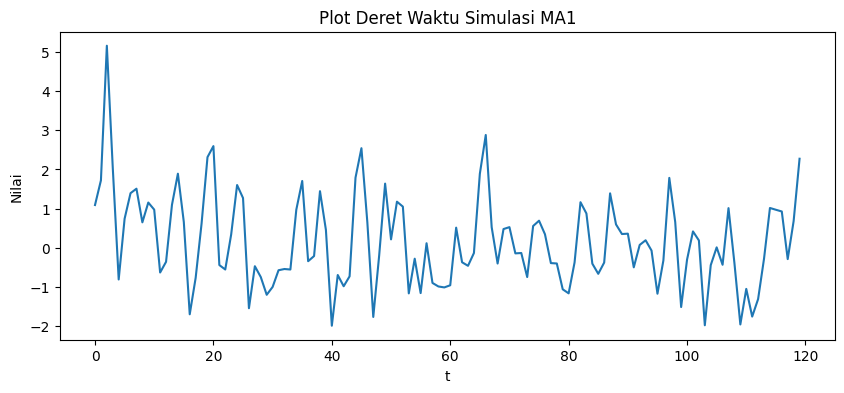

In [ ]:
x_ma1 = ArmaProcess(ar=[1], ma=[1, 0.6])
np.random.seed(SEED)
x_ma1 = x_ma1.generate_sample(nsample=120)
x_ma1 = pd.Series(x_ma1, name="MA1")

plt.figure(figsize=(10,4))
plt.plot(x_ma1)
plt.title('Plot Deret Waktu Simulasi MA1')
plt.xlabel('t'); plt.ylabel('Nilai')
plt.show()

### 2. Pembagian Data Latih dan Data Uji

In [ ]:
n = len(x_ma1)
n_train = int(round(0.8 * n))
train_ma1, test_ma1 = x_ma1.iloc[:n_train], x_ma1.iloc[n_train:]
print('n_train =', len(train_ma1), ' n_test =', len(test_ma1))

n_train = 96  n_test = 24


### 3. Plot ACF, PACF, dan EACF Data Latih

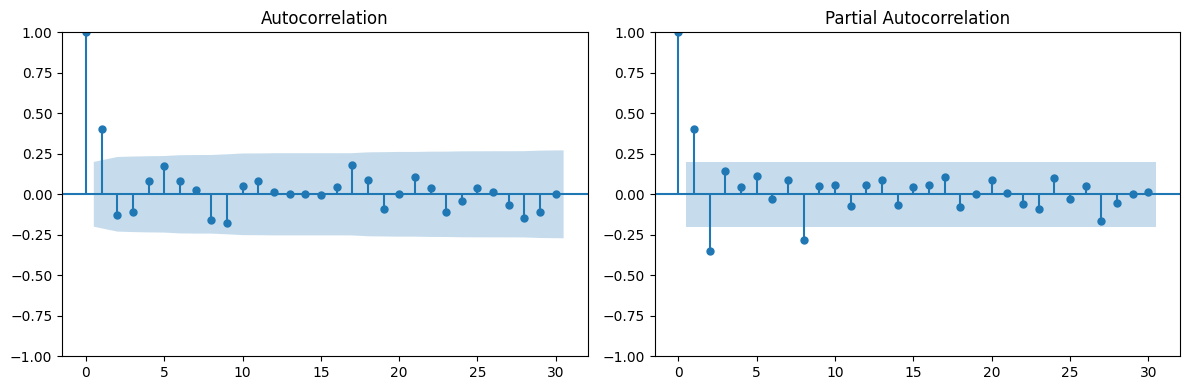

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(train_ma1, lags=min(30, len(train_ma1)-1), ax=axes[0])
plot_pacf(train_ma1, lags=min(30, len(train_ma1)//2-1), ax=axes[1], method='ywm')
plt.tight_layout(); plt.show()

In [ ]:
val, sym = eacf(train_ma1.values, ar_max=4, ma_max=5)
print_eacf(sym)

AR/MA  0  1  2  3  4  5
    0 x  o  o  o  o  o
    1 o  x  o  o  o  o
    2 o  o  o  o  o  o
    3 o  o  o  o  o  o
    4 o  o  o  o  x  o


### 4. Pengepasan Model, Overfitting, dan Pemilihan Model Terbaik

In [ ]:
kandidat_ma1 = {
    "MA(1)": (0, 0, 1),
    "AR(1)": (1, 0, 0),
    "MA(2)_overfit": (0, 0, 2),
    "ARMA(1,1)_overfit": (1, 0, 1),
}

In [ ]:
fits_ma1 = {}
rows = []
for nama, order in kandidat_ma1.items():
    m = ARIMA(train_ma1, order=order).fit()
    fits_ma1[nama] = m
    rows.append({'model': nama, 'order': order, 'AIC': m.aic, 'BIC': m.bic})
pd.DataFrame(rows)

,model,order,AIC,BIC
0,MA(1),"(0, 0, 1)",276.591035,284.284080
1,AR(1),"(1, 0, 0)",292.547784,300.240828
2,MA(2)_overfit,"(0, 0, 2)",277.674778,287.932171
3,"ARMA(1,1)_overfit","(1, 0, 1)",277.721643,287.979036


In [ ]:
best_ma1 = fits_ma1['MA(1)']
print(best_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                    MA1   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -135.296
Date:                Wed, 23 Sep 2026   AIC                            276.591
Time:                        08:46:53   BIC                            284.284
Sample:                             0   HQIC                           279.701
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2271      0.186      1.222      0.222      -0.137       0.591
ma.L1          0.7251      0.084      8.643      0.000       0.561       0.889
sigma2         0.9734      0.111      8.735      0.0

### 5. Diagnostik Sisaan Model Terbaik

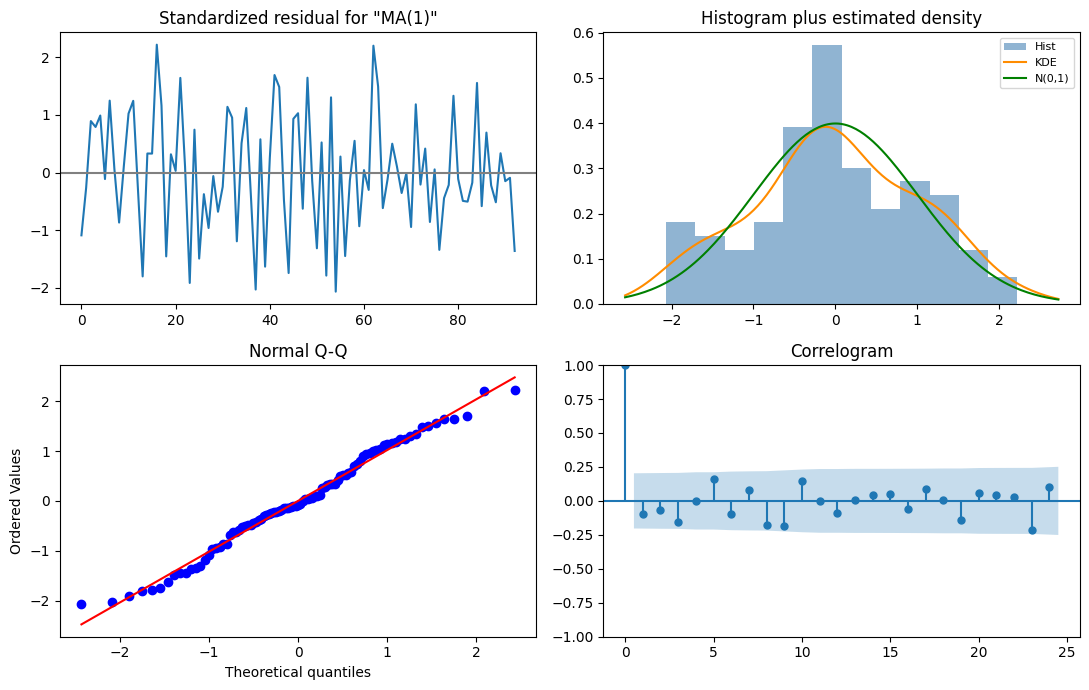

Ljung-Box (lag 10) : stat=17.030  p-value=0.0737
ARCH (nlags=10)    : p-value=0.3267
Runs test          : stat=1.178  p-value=0.2386
Shapiro-Wilk       : stat=0.985  p-value=0.3534
Jarque-Bera        : stat=1.150  p-value=0.5627


In [ ]:
skip = 3  # 3 observasi awal residual state-space dibuang (transient inisialisasi Kalman filter)
resid = best_ma1.resid[skip:]
resid_arr = resid.values if hasattr(resid, 'values') else np.asarray(resid)
resid_std = (resid_arr - resid_arr.mean()) / resid_arr.std()  # sisaan terstandardisasi

fig, axes = plt.subplots(2, 2, figsize=(11,7))

axes[0,0].plot(resid_std); axes[0,0].axhline(0, color='gray')
axes[0,0].set_title('Standardized residual for "MA(1)"')

axes[0,1].hist(resid_std, bins=12, density=True, alpha=0.6, color='steelblue', label='Hist')
xs = np.linspace(resid_std.min()-0.5, resid_std.max()+0.5, 200)
kde = stats.gaussian_kde(resid_std)
axes[0,1].plot(xs, kde(xs), color='darkorange', label='KDE')
axes[0,1].plot(xs, stats.norm.pdf(xs, 0, 1), color='green', label='N(0,1)')
axes[0,1].set_title('Histogram plus estimated density'); axes[0,1].legend(fontsize=8)

stats.probplot(resid_std, dist='norm', plot=axes[1,0]); axes[1,0].set_title('Normal Q-Q')

plot_acf(resid_std, lags=min(24, len(resid_std)//2-2), ax=axes[1,1]); axes[1,1].set_title('Correlogram')

plt.tight_layout(); plt.show()

diagnose_residual(resid_std)

### 6. Peramalan Sepanjang Periode Data Uji dan Evaluasi

In [ ]:
fitted_train = best_ma1.fittedvalues
mape_train = mape(train_ma1.values[skip:], fitted_train.values[skip:])
rmse_train = rmse(train_ma1.values[skip:], fitted_train.values[skip:])

fc = best_ma1.get_forecast(steps=len(test_ma1))
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

mape_test = mape(test_ma1.values, fc_mean.values)
rmse_test = rmse(test_ma1.values, fc_mean.values)

print(f'MAPE train = {mape_train:.2f}%   MAPE test = {mape_test:.2f}%')
print(f'RMSE train = {rmse_train:.4f}   RMSE test = {rmse_test:.4f}')

MAPE train = 109.23%   MAPE test = 187.32%
RMSE train = 0.8992   RMSE test = 1.1570


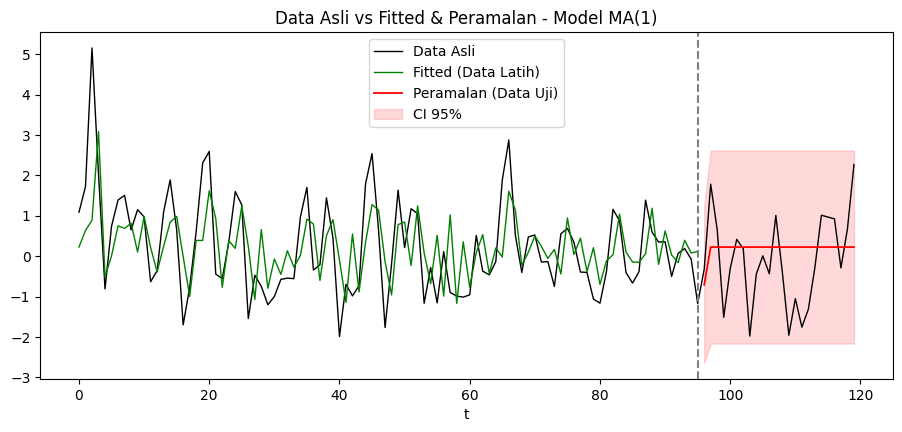

In [ ]:
plt.figure(figsize=(11,4.5))
plt.plot(x_ma1.index, x_ma1.values, label='Data Asli', color='black', linewidth=1)
plt.plot(train_ma1.index, fitted_train.values, label='Fitted (Data Latih)', color='green', linewidth=1)
plt.plot(test_ma1.index, fc_mean.values, label='Peramalan (Data Uji)', color='red', linewidth=1.3)
plt.fill_between(test_ma1.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='red', alpha=0.15, label='CI 95%')
plt.axvline(train_ma1.index[-1], color='gray', linestyle='--')
plt.title('Data Asli vs Fitted & Peramalan - Model MA(1)')
plt.xlabel('t'); plt.legend(); plt.show()

## DERET 2 — Simulasi AR(2)

Parameter simulasi: &phi;<sub>1</sub> = 0.9, &phi;<sub>2</sub> = -0.5, n = 100

### 1. Simulasi & Plot Deret Waktu

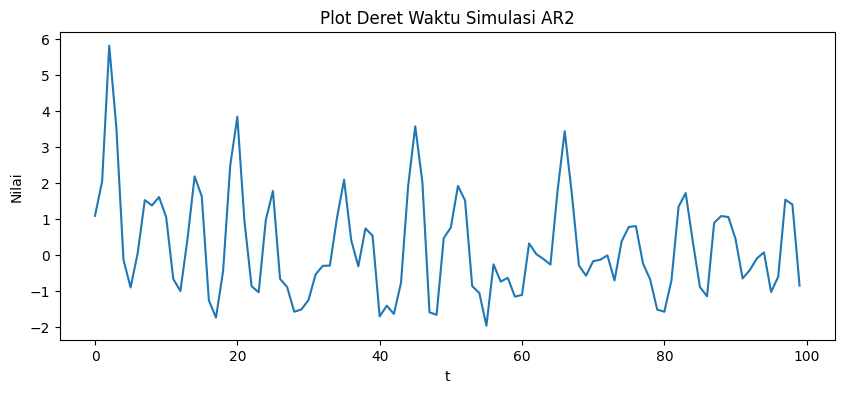

In [ ]:
x_ar2 = ArmaProcess(ar=[1, -0.9, 0.5], ma=[1])
np.random.seed(SEED)
x_ar2 = x_ar2.generate_sample(nsample=100)
x_ar2 = pd.Series(x_ar2, name="AR2")

plt.figure(figsize=(10,4))
plt.plot(x_ar2)
plt.title('Plot Deret Waktu Simulasi AR2')
plt.xlabel('t'); plt.ylabel('Nilai')
plt.show()

### 2. Pembagian Data Latih dan Data Uji

In [ ]:
n = len(x_ar2)
n_train = int(round(0.8 * n))
train_ar2, test_ar2 = x_ar2.iloc[:n_train], x_ar2.iloc[n_train:]
print('n_train =', len(train_ar2), ' n_test =', len(test_ar2))

n_train = 80  n_test = 20


### 3. Plot ACF, PACF, dan EACF Data Latih

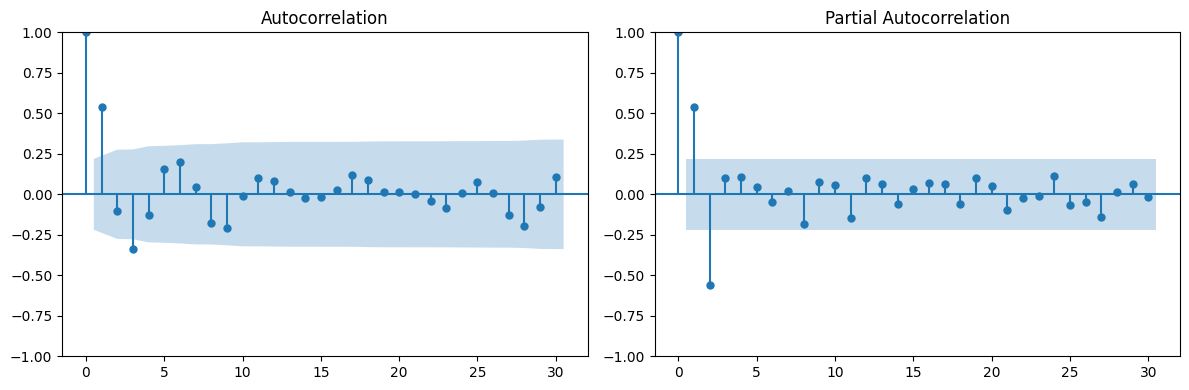

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(train_ar2, lags=min(30, len(train_ar2)-1), ax=axes[0])
plot_pacf(train_ar2, lags=min(30, len(train_ar2)//2-1), ax=axes[1], method='ywm')
plt.tight_layout(); plt.show()

In [ ]:
val, sym = eacf(train_ar2.values, ar_max=4, ma_max=4)
print_eacf(sym)

AR/MA  0  1  2  3  4
    0 x  o  x  o  o
    1 x  x  x  o  x
    2 o  o  o  o  o
    3 o  o  o  o  o
    4 o  o  o  o  o


### 4. Pengepasan Model, Overfitting, dan Pemilihan Model Terbaik

In [ ]:
kandidat_ar2 = {
    "AR(1)": (1, 0, 0),
    "AR(2)": (2, 0, 0),
    "AR(3)_overfit": (3, 0, 0),
    "ARMA(2,1)_overfit": (2, 0, 1),
}

In [ ]:
fits_ar2 = {}
rows = []
for nama, order in kandidat_ar2.items():
    m = ARIMA(train_ar2, order=order).fit()
    fits_ar2[nama] = m
    rows.append({'model': nama, 'order': order, 'AIC': m.aic, 'BIC': m.bic})
pd.DataFrame(rows)

,model,order,AIC,BIC
0,AR(1),"(1, 0, 0)",271.661305,278.807385
1,AR(2),"(2, 0, 0)",243.361200,252.889307
2,AR(3)_overfit,"(3, 0, 0)",244.391646,256.301779
3,"ARMA(2,1)_overfit","(2, 0, 1)",244.634331,256.544464


In [ ]:
best_ar2 = fits_ar2['AR(2)']
print(best_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                    AR2   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -117.681
Date:                Wed, 23 Sep 2026   AIC                            243.361
Time:                        08:46:56   BIC                            252.889
Sample:                             0   HQIC                           247.181
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2643      0.185      1.428      0.153      -0.098       0.627
ar.L1          0.8492      0.133      6.395      0.000       0.589       1.109
ar.L2         -0.5631      0.119     -4.740      0.0

### 5. Diagnostik Sisaan Model Terbaik

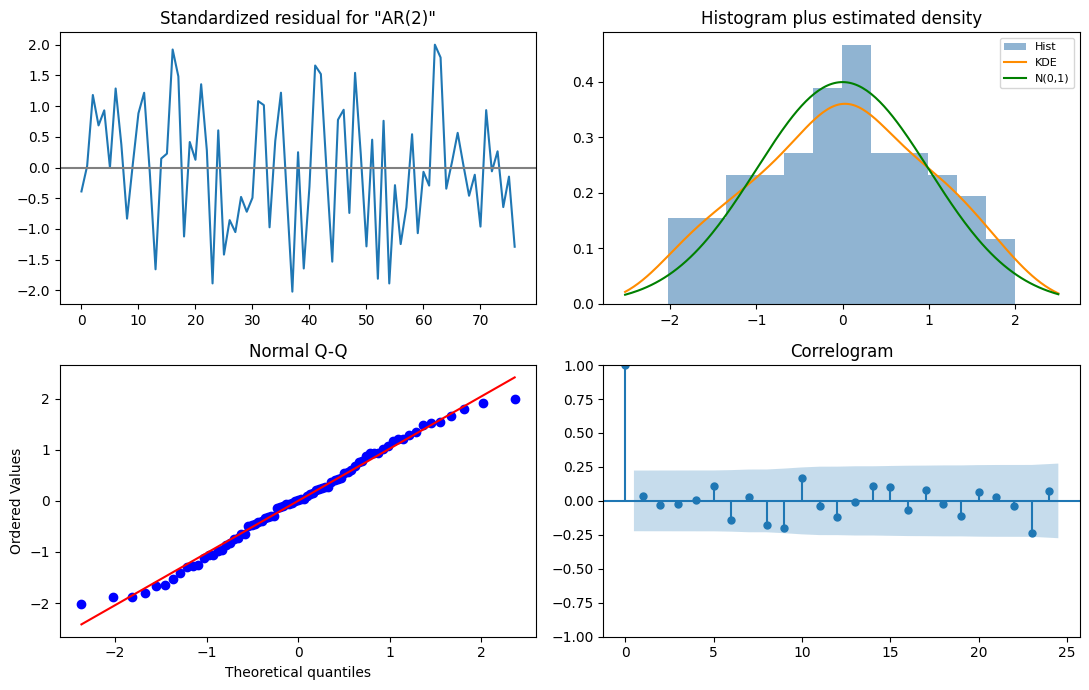

Ljung-Box (lag 10) : stat=11.995  p-value=0.2854
ARCH (nlags=10)    : p-value=0.7093
Runs test          : stat=-0.113  p-value=0.9098
Shapiro-Wilk       : stat=0.984  p-value=0.4376
Jarque-Bera        : stat=1.702  p-value=0.4270


In [ ]:
skip = 3  # 3 observasi awal residual state-space dibuang (transient inisialisasi Kalman filter)
resid = best_ar2.resid[skip:]
resid_arr = resid.values if hasattr(resid, 'values') else np.asarray(resid)
resid_std = (resid_arr - resid_arr.mean()) / resid_arr.std()  # sisaan terstandardisasi

fig, axes = plt.subplots(2, 2, figsize=(11,7))

axes[0,0].plot(resid_std); axes[0,0].axhline(0, color='gray')
axes[0,0].set_title('Standardized residual for "AR(2)"')

axes[0,1].hist(resid_std, bins=12, density=True, alpha=0.6, color='steelblue', label='Hist')
xs = np.linspace(resid_std.min()-0.5, resid_std.max()+0.5, 200)
kde = stats.gaussian_kde(resid_std)
axes[0,1].plot(xs, kde(xs), color='darkorange', label='KDE')
axes[0,1].plot(xs, stats.norm.pdf(xs, 0, 1), color='green', label='N(0,1)')
axes[0,1].set_title('Histogram plus estimated density'); axes[0,1].legend(fontsize=8)

stats.probplot(resid_std, dist='norm', plot=axes[1,0]); axes[1,0].set_title('Normal Q-Q')

plot_acf(resid_std, lags=min(24, len(resid_std)//2-2), ax=axes[1,1]); axes[1,1].set_title('Correlogram')

plt.tight_layout(); plt.show()

diagnose_residual(resid_std)

### 6. Peramalan Sepanjang Periode Data Uji dan Evaluasi

In [ ]:
fitted_train = best_ar2.fittedvalues
mape_train = mape(train_ar2.values[skip:], fitted_train.values[skip:])
rmse_train = rmse(train_ar2.values[skip:], fitted_train.values[skip:])

fc = best_ar2.get_forecast(steps=len(test_ar2))
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

mape_test = mape(test_ar2.values, fc_mean.values)
rmse_test = rmse(test_ar2.values, fc_mean.values)

print(f'MAPE train = {mape_train:.2f}%   MAPE test = {mape_test:.2f}%')
print(f'RMSE train = {rmse_train:.4f}   RMSE test = {rmse_test:.4f}')

MAPE train = 178.21%   MAPE test = 111.29%
RMSE train = 0.9241   RMSE test = 0.8598


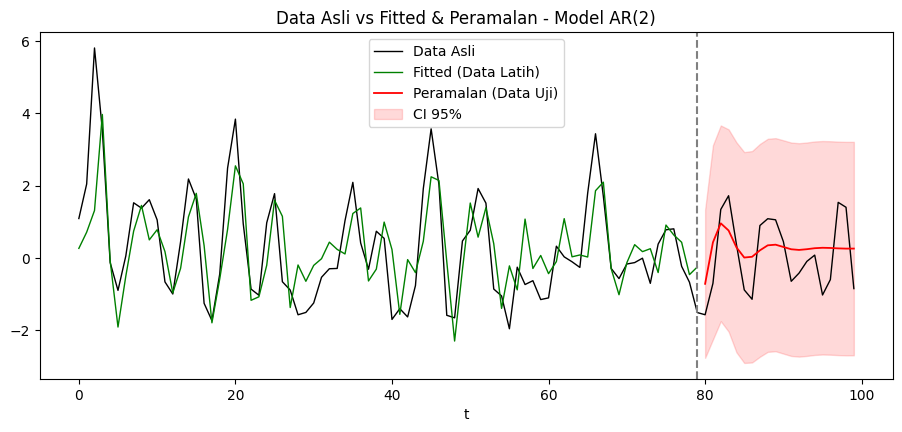

In [ ]:
plt.figure(figsize=(11,4.5))
plt.plot(x_ar2.index, x_ar2.values, label='Data Asli', color='black', linewidth=1)
plt.plot(train_ar2.index, fitted_train.values, label='Fitted (Data Latih)', color='green', linewidth=1)
plt.plot(test_ar2.index, fc_mean.values, label='Peramalan (Data Uji)', color='red', linewidth=1.3)
plt.fill_between(test_ar2.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='red', alpha=0.15, label='CI 95%')
plt.axvline(train_ar2.index[-1], color='gray', linestyle='--')
plt.title('Data Asli vs Fitted & Peramalan - Model AR(2)')
plt.xlabel('t'); plt.legend(); plt.show()

## DERET 3 — Simulasi ARMA(1,1)

Parameter simulasi: &phi; = 0.4, &theta; = 0.6, n = 200

### 1. Simulasi & Plot Deret Waktu

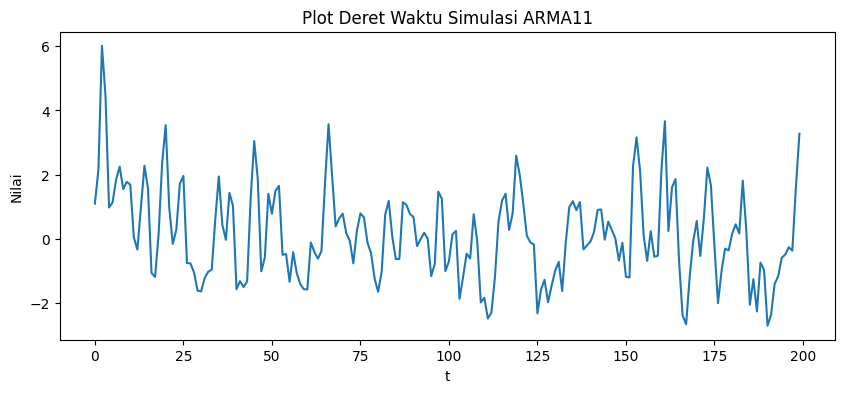

In [ ]:
x_arma11 = ArmaProcess(ar=[1, -0.4], ma=[1, 0.6])
np.random.seed(SEED)
x_arma11 = x_arma11.generate_sample(nsample=200)
x_arma11 = pd.Series(x_arma11, name="ARMA11")

plt.figure(figsize=(10,4))
plt.plot(x_arma11)
plt.title('Plot Deret Waktu Simulasi ARMA11')
plt.xlabel('t'); plt.ylabel('Nilai')
plt.show()

### 2. Pembagian Data Latih dan Data Uji

In [ ]:
n = len(x_arma11)
n_train = int(round(0.85 * n))
train_arma11, test_arma11 = x_arma11.iloc[:n_train], x_arma11.iloc[n_train:]
print('n_train =', len(train_arma11), ' n_test =', len(test_arma11))

n_train = 170  n_test = 30


### 3. Plot ACF, PACF, dan EACF Data Latih

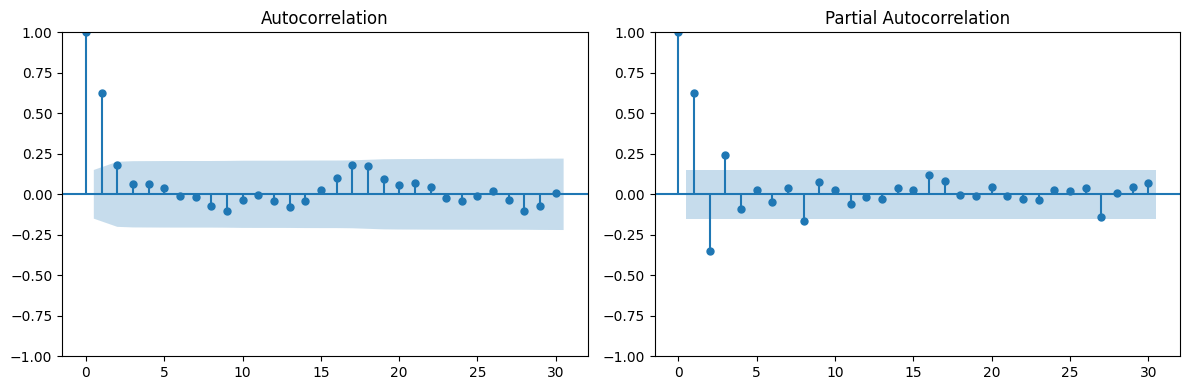

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(train_arma11, lags=min(30, len(train_arma11)-1), ax=axes[0])
plot_pacf(train_arma11, lags=min(30, len(train_arma11)//2-1), ax=axes[1], method='ywm')
plt.tight_layout(); plt.show()

In [ ]:
val, sym = eacf(train_arma11.values, ar_max=4, ma_max=5)
print_eacf(sym)

AR/MA  0  1  2  3  4  5
    0 x  x  o  o  o  o
    1 x  x  x  o  o  o
    2 o  o  x  o  o  o
    3 o  o  o  o  o  o
    4 o  o  o  o  o  o


### 4. Pengepasan Model, Overfitting, dan Pemilihan Model Terbaik

In [ ]:
kandidat_arma11 = {
    "AR(1)": (1, 0, 0),
    "MA(1)": (0, 0, 1),
    "ARMA(1,1)": (1, 0, 1),
    "ARMA(2,1)_overfit": (2, 0, 1),
    "ARMA(1,2)_overfit": (1, 0, 2),
}

In [ ]:
fits_arma11 = {}
rows = []
for nama, order in kandidat_arma11.items():
    m = ARIMA(train_arma11, order=order).fit()
    fits_arma11[nama] = m
    rows.append({'model': nama, 'order': order, 'AIC': m.aic, 'BIC': m.bic})
pd.DataFrame(rows)

,model,order,AIC,BIC
0,AR(1),"(1, 0, 0)",524.779970,534.187365
1,MA(1),"(0, 0, 1)",499.196604,508.603999
2,"ARMA(1,1)","(1, 0, 1)",490.948930,503.492124
3,"ARMA(2,1)_overfit","(2, 0, 1)",492.931270,508.610262
4,"ARMA(1,2)_overfit","(1, 0, 2)",492.927504,508.606496


In [ ]:
best_arma11 = fits_arma11['ARMA(1,1)']
print(best_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:                 ARMA11   No. Observations:                  170
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -241.474
Date:                Wed, 23 Sep 2026   AIC                            490.949
Time:                        08:47:00   BIC                            503.492
Sample:                             0   HQIC                           496.039
                                - 170                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2044      0.192      1.065      0.287      -0.172       0.580
ar.L1          0.2993      0.094      3.184      0.001       0.115       0.484
ma.L1          0.6728      0.070      9.633      0.0

### 5. Diagnostik Sisaan Model Terbaik

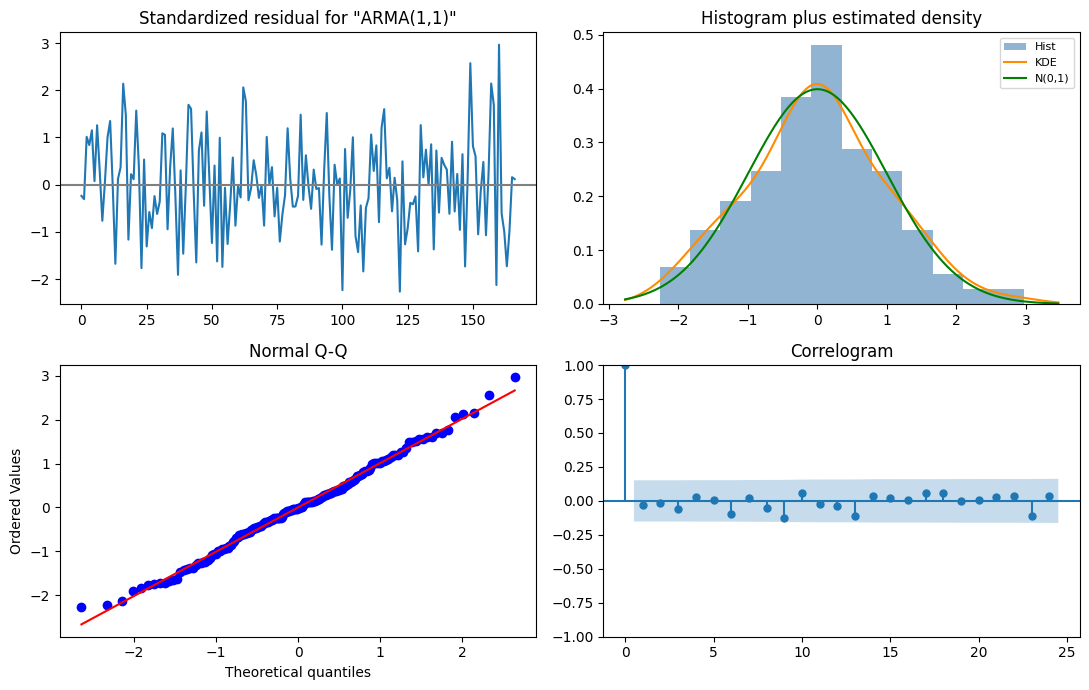

Ljung-Box (lag 10) : stat=6.826  p-value=0.7418
ARCH (nlags=10)    : p-value=0.3569
Runs test          : stat=-0.066  p-value=0.9473
Shapiro-Wilk       : stat=0.994  p-value=0.7482
Jarque-Bera        : stat=0.476  p-value=0.7880


In [ ]:
skip = 3  # 3 observasi awal residual state-space dibuang (transient inisialisasi Kalman filter)
resid = best_arma11.resid[skip:]
resid_arr = resid.values if hasattr(resid, 'values') else np.asarray(resid)
resid_std = (resid_arr - resid_arr.mean()) / resid_arr.std()  # sisaan terstandardisasi

fig, axes = plt.subplots(2, 2, figsize=(11,7))

axes[0,0].plot(resid_std); axes[0,0].axhline(0, color='gray')
axes[0,0].set_title('Standardized residual for "ARMA(1,1)"')

axes[0,1].hist(resid_std, bins=12, density=True, alpha=0.6, color='steelblue', label='Hist')
xs = np.linspace(resid_std.min()-0.5, resid_std.max()+0.5, 200)
kde = stats.gaussian_kde(resid_std)
axes[0,1].plot(xs, kde(xs), color='darkorange', label='KDE')
axes[0,1].plot(xs, stats.norm.pdf(xs, 0, 1), color='green', label='N(0,1)')
axes[0,1].set_title('Histogram plus estimated density'); axes[0,1].legend(fontsize=8)

stats.probplot(resid_std, dist='norm', plot=axes[1,0]); axes[1,0].set_title('Normal Q-Q')

plot_acf(resid_std, lags=min(24, len(resid_std)//2-2), ax=axes[1,1]); axes[1,1].set_title('Correlogram')

plt.tight_layout(); plt.show()

diagnose_residual(resid_std)

### 6. Peramalan Sepanjang Periode Data Uji dan Evaluasi

In [ ]:
fitted_train = best_arma11.fittedvalues
mape_train = mape(train_arma11.values[skip:], fitted_train.values[skip:])
rmse_train = rmse(train_arma11.values[skip:], fitted_train.values[skip:])

fc = best_arma11.get_forecast(steps=len(test_arma11))
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

mape_test = mape(test_arma11.values, fc_mean.values)
rmse_test = rmse(test_arma11.values, fc_mean.values)

print(f'MAPE train = {mape_train:.2f}%   MAPE test = {mape_test:.2f}%')
print(f'RMSE train = {rmse_train:.4f}   RMSE test = {rmse_test:.4f}')

MAPE train = 189.42%   MAPE test = 107.52%
RMSE train = 0.9449   RMSE test = 1.4756


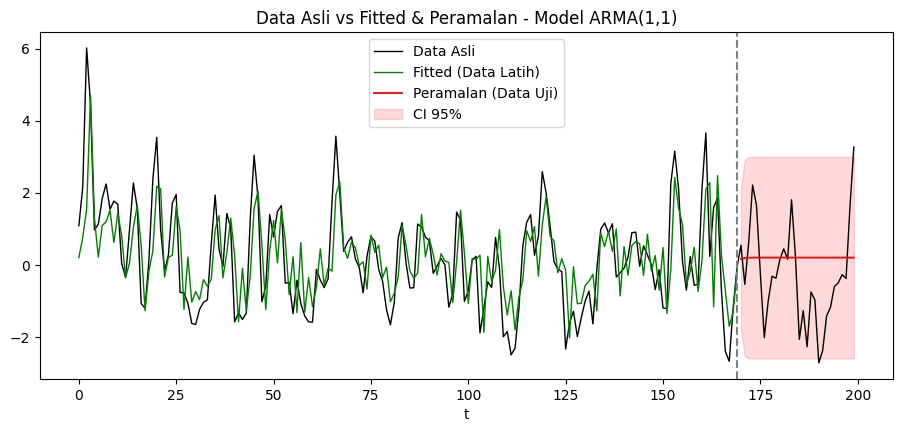

In [ ]:
plt.figure(figsize=(11,4.5))
plt.plot(x_arma11.index, x_arma11.values, label='Data Asli', color='black', linewidth=1)
plt.plot(train_arma11.index, fitted_train.values, label='Fitted (Data Latih)', color='green', linewidth=1)
plt.plot(test_arma11.index, fc_mean.values, label='Peramalan (Data Uji)', color='red', linewidth=1.3)
plt.fill_between(test_arma11.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='red', alpha=0.15, label='CI 95%')
plt.axvline(train_arma11.index[-1], color='gray', linestyle='--')
plt.title('Data Asli vs Fitted & Peramalan - Model ARMA(1,1)')
plt.xlabel('t'); plt.legend(); plt.show()